In [83]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns

In [84]:
# /content/house-train.csv
df = pd.read_csv('/content/train.csv', usecols=['Age', 'Fare', 'Survived'])

In [85]:
df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [86]:
df.isnull().mean() * 100

,0
Survived,0.00000
Age,19.86532
Fare,0.00000


In [87]:
X = df.drop(columns=['Survived'])
y = df['Survived']

In [88]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [89]:
X_train

,Age,Fare
331,45.5,28.5000
733,23.0,13.0000
382,32.0,7.9250
704,26.0,7.8542
813,6.0,31.2750
...,...,...
106,21.0,7.6500
270,NaN,31.0000
860,41.0,14.1083
435,14.0,120.0000


In [90]:
X_train['Age_imputed'] = X_train['Age']
X_test['Age_imputed'] = X_test['Age']

In [91]:
X_train.loc[X_train['Age_imputed'].isnull(), 'Age_imputed'] = (
    X_train['Age'].dropna()
    .sample(X_train['Age'].isnull().sum())
    .values
)

X_test.loc[X_test['Age_imputed'].isnull(), 'Age_imputed'] = (
    X_test['Age'].dropna()
    .sample(X_test['Age'].isnull().sum())
    .values
)

In [92]:
X_train['Age'].dropna().sample(X_train['Age'].isnull().sum()).values

array([32.  , 34.  , 30.  , 28.  , 51.  ,  2.  , 55.  , 44.  , 16.  ,
       50.  , 18.  , 33.  , 47.  , 22.  ,  1.  , 26.  , 30.  , 19.  ,
       32.  , 58.  , 24.  , 21.  , 54.  , 51.  , 45.5 , 52.  , 18.  ,
       42.  , 32.  , 37.  , 19.  ,  5.  , 22.  , 41.  , 24.  , 21.  ,
       39.  , 16.  , 30.  ,  4.  , 24.  , 21.  , 62.  , 31.  , 30.  ,
       45.  , 18.  , 17.  ,  5.  , 19.  , 14.  , 28.5 , 24.  , 33.  ,
       22.  , 32.  , 56.  , 49.  , 34.  , 11.  , 29.  , 36.5 , 16.  ,
       32.  , 45.  , 22.  ,  1.  , 43.  , 35.  , 16.  , 54.  , 28.  ,
       30.  , 63.  , 34.  , 24.  , 29.  ,  0.42, 17.  , 24.  , 27.  ,
       58.  , 31.  , 35.  , 48.  , 55.5 , 26.  , 42.  ,  9.  ,  1.  ,
       39.  , 24.  , 32.  , 22.  , 30.  ,  1.  , 45.  , 35.  , 27.  ,
       38.  , 22.  , 36.  , 50.  , 49.  , 25.  , 25.  , 21.  , 26.  ,
       17.  , 19.  ,  8.  , 28.  , 29.  , 44.  , 24.  , 31.  , 35.  ,
       32.  , 24.  , 23.  , 28.  , 26.  , 29.  ,  0.67, 26.  , 34.  ,
       28.  , 16.  ,

In [93]:
X_train['Age'].isnull().sum()

np.int64(140)

In [94]:
X_train

,Age,Fare,Age_imputed
331,45.5,28.5000,45.5
733,23.0,13.0000,23.0
382,32.0,7.9250,32.0
704,26.0,7.8542,26.0
813,6.0,31.2750,6.0
...,...,...,...
106,21.0,7.6500,21.0
270,NaN,31.0000,33.0
860,41.0,14.1083,41.0
435,14.0,120.0000,14.0


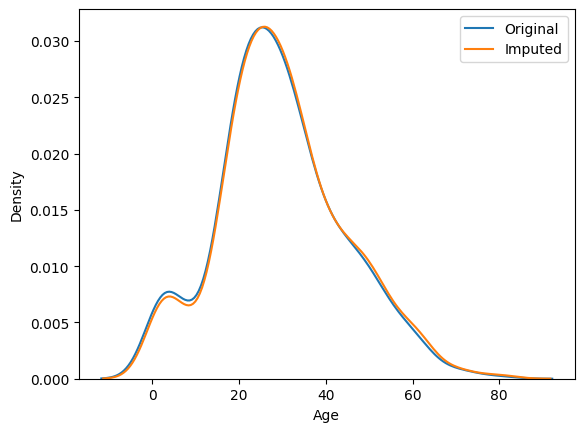

In [95]:
sns.kdeplot(X_train['Age'], label='Original')
sns.kdeplot(X_train['Age_imputed'], label='Imputed')

plt.legend()
plt.show()

In [96]:
print('Original variable variance: ', X_train['Age'].var())
print('Variance after random imputation: ', X_train['Age_imputed'].var())

Original variable variance:  210.2517072477438
Variance after random imputation:  213.62668284818034


In [97]:
X_train[['Fare', 'Age', 'Age_imputed']].cov()

,Fare,Age,Age_imputed
Fare,2700.831981,71.580633,63.929398
Age,71.580633,210.251707,210.251707
Age_imputed,63.929398,210.251707,213.626683


<Axes: >

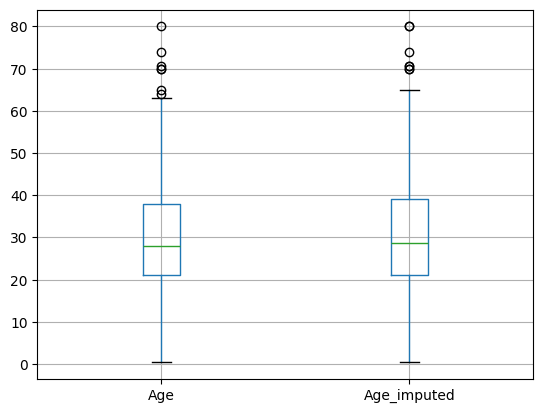

In [98]:
X_train[['Age', 'Age_imputed']].boxplot()

In [99]:
observation = X_train.iloc[0]

In [100]:
sampled_value = X_train['Age'].dropna().sample(1, random_state=int(observation['Fare']))

In [101]:
data = pd.read_csv('house-train.csv',usecols=['GarageQual','FireplaceQu', 'SalePrice'])

In [102]:
data.head()

,FireplaceQu,GarageQual,SalePrice
0,NaN,TA,208500
1,TA,TA,181500
2,TA,TA,223500
3,Gd,TA,140000
4,TA,TA,250000


In [103]:
data.isnull().mean() * 100

,0
FireplaceQu,47.260274
GarageQual,5.547945
SalePrice,0.000000


In [104]:
X = data
y = data['SalePrice']

In [105]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [106]:
X_train['GarageQual_imputed'] = X_train['GarageQual']
X_test['GarageQual_imputed'] = X_test['GarageQual']

X_train['FireplaceQu_imputed'] = X_train['FireplaceQu']
X_test['FireplaceQu_imputed'] = X_test['FireplaceQu']

In [107]:
X_train.sample(5)

,FireplaceQu,GarageQual,SalePrice,GarageQual_imputed,FireplaceQu_imputed
330,NaN,TA,119000,TA,NaN
564,TA,TA,268000,TA,TA
963,NaN,TA,239000,TA,NaN
883,NaN,TA,118500,TA,NaN
1073,NaN,TA,159500,TA,NaN


In [108]:
# GarageQual

X_train.loc[X_train['GarageQual_imputed'].isnull(), 'GarageQual_imputed'] = (
    X_train['GarageQual'].dropna()
    .sample(X_train['GarageQual'].isnull().sum())
    .values
)

X_test.loc[X_test['GarageQual_imputed'].isnull(), 'GarageQual_imputed'] = (
    X_test['GarageQual'].dropna()
    .sample(X_test['GarageQual'].isnull().sum())
    .values
)


# FireplaceQu

X_train.loc[X_train['FireplaceQu_imputed'].isnull(), 'FireplaceQu_imputed'] = (
    X_train['FireplaceQu'].dropna()
    .sample(X_train['FireplaceQu'].isnull().sum())
    .values
)

X_test.loc[X_test['FireplaceQu_imputed'].isnull(), 'FireplaceQu_imputed'] = (
    X_test['FireplaceQu'].dropna()
    .sample(X_test['FireplaceQu'].isnull().sum())
    .values
)

In [112]:
temp = pd.concat(
        [
            X_train['GarageQual'].value_counts() / len(X_train['GarageQual'].dropna()),
            X_train['GarageQual_imputed'].value_counts() / len(X_train)
        ],
        axis=1)

temp.columns = ['original', 'imputed']

temp

,original,imputed
TA,0.951043,0.951199
Fa,0.037171,0.036815
Gd,0.009973,0.010274
Po,0.000907,0.000856
Ex,0.000907,0.000856


In [113]:
temp = pd.concat(
        [
            X_train['FireplaceQu'].value_counts() / len(X_train['FireplaceQu'].dropna()),
            X_train['FireplaceQu_imputed'].value_counts() / len(df)
        ],
        axis=1)

temp.columns = ['original', 'imputed']

temp

,original,imputed
Gd,0.494272,0.650954
TA,0.412439,0.539843
Fa,0.040917,0.052750
Po,0.027823,0.035915
Ex,0.024550,0.031425


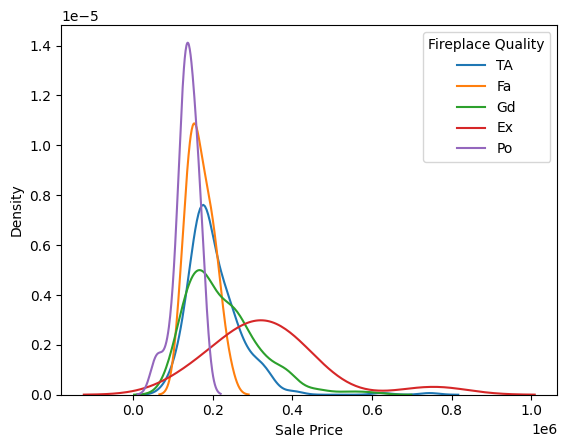

In [121]:
for category in X_train['FireplaceQu'].dropna().unique():
    sns.kdeplot(
        data=X_train[X_train['FireplaceQu'] == category],
        x='SalePrice',
        label=category
    )

plt.legend(title='Fireplace Quality')
plt.xlabel('Sale Price')
plt.ylabel('Density')
plt.show()

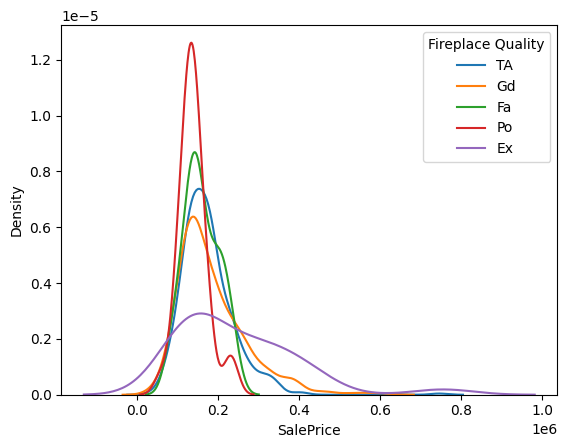

In [123]:
for category in X_train['FireplaceQu_imputed'].dropna().unique():
    sns.kdeplot(
        X_train[X_train['FireplaceQu_imputed'] == category]['SalePrice'],
        label=category
    )

plt.legend(title='Fireplace Quality')
plt.show()